In [7]:
import os
os.getcwd()

'C:\\Users\\khkim'

In [8]:
import os
print(os.getcwd())
print(os.listdir())

C:\Users\khkim
['.arduinoIDE', '.digital.cfg', '.gitconfig', '.idlerc', '.ipynb_checkpoints', '.ipython', '.jdks', '.jupyter', '.matplotlib', 'AppData', 'Application Data', 'Contacts', 'Cookies', 'Documents', 'Downloads', 'Favorites', 'i3q6bSoc4a0', 'IdeaProjects', 'Links', 'Local Settings', 'Music', 'My Documents', 'NetHood', 'NTUSER.DAT', 'ntuser.dat.LOG1', 'ntuser.dat.LOG2', 'NTUSER.DAT{738b258f-681e-11f0-af72-ab43b25bdfc5}.TM.blf', 'NTUSER.DAT{738b258f-681e-11f0-af72-ab43b25bdfc5}.TMContainer00000000000000000001.regtrans-ms', 'NTUSER.DAT{738b258f-681e-11f0-af72-ab43b25bdfc5}.TMContainer00000000000000000002.regtrans-ms', 'ntuser.ini', 'OneDrive', 'PrintHood', 'quartus2.ini', 'quartus2.qreg', 'Recent', 'Saved Games', 'Searches', 'SendTo', 'simulation', 'Start Menu', 'Templates', 'Untitled.ipynb', 'Untitled1.ipynb', 'ValerieXu-checkpoint.ipynb', 'ValerieXu.ipynb', 'venv', 'Videos', 'Year_1849_1865.geojson']


In [9]:
import json

file_path = "Year_1849_1865.geojson"

with open(file_path, "r", encoding="utf-8") as f:
    geojson_data = json.load(f)

Dataset loaded.
Rows: 320, Columns: 18

Columns:
['Year', 'Date', 'State', 'Sublocation', 'Location', 'Lat', 'Long', 'Description', 'Source', 'Type', 'Rioter Classification', 'Target Classification', 'Actions', 'Recorded # Killed', 'Recorded # Injured', 'Persons Named as Rioters', 'Persons Named as Targets', 'Note']


,Year,Date,State,Sublocation,Location,Lat,Long,Description,Source,Type,Rioter Classification,Target Classification,Actions,Recorded # Killed,Recorded # Injured,Persons Named as Rioters,Persons Named as Targets,Note
0,1849,1849/01,California,Dry Diggings,Dry Diggings,38.727510,-120.799800,Janurary: Three men hanged. One for alleged ho...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1849,NaN,Arkansas,Phillips Co.,Phillips Co. AR,34.379810,-90.819060,Burning of enslaved man for allegedly murderin...,"Orville W. Taylor, Negro Slavery on Arkansas (...",Racial; Slavery; Vigilante; Law,White; Vigilante,Black; Slave; Alleged Criminal; Alleged Murderer,Lethal Violence; Mutilation,1.0,NaN,NaN,NaN,PTH
2,1849,1849/05,New York,New York City,NYC,40.720368,-74.001098,May: Astor Place Riot. Long-time feud between ...,"Cook.Armies, p.24-27",Theater,Unknown,Theater; Actor; Legal; Law Officer; Military; ...,Lethal Violence,22.0,NaN,Edwin Forrest,William C. MacReady,NaN
3,1849,1849/07,Pennsylvania,Philadelphia,Philadelphia,39.901530,-75.176711,June: Fire purposefully set so a gang could at...,"Scharf and Wescott, p.691-692",Firefighter,Firefighter; Franklin Hose; Gang,Firefighter; Franklin Hose; Gang,Lethal Violence,1.0,NaN,NaN,NaN,NaN
4,1849,1849/07,Illinois,Massac Co.,"Massac Co., Illinois",37.240106,-88.724884,July: Flatheads and Regulators fight at Linn F...,"Eteheson. ""Good Men,"" p.17;Lethal Imagination,...",Vigilante; Law; Gang,Vigilante; Regulator (Vigilante); Gang; Flathead,Vigilante; Regulator (Vigilante); Gang; Flathead,Lethal Violence; Non-Lethal Violence,3.0,6.0,NaN,NaN,NaN



Shape after cleaning: (320, 18)

Counts by region:


,count
region,
West/North,245
South/Border South,75



Counts by incident group:


,count
incident_group,
Racial/Slavery-Related,188
Other,132



Raw counts by region and incident group:


incident_group,Other,Racial/Slavery-Related
region,,
South/Border South,16,59
West/North,116,129



Percentages within each region:


incident_group,Other,Racial/Slavery-Related
region,,
South/Border South,21.33,78.67
West/North,47.35,52.65


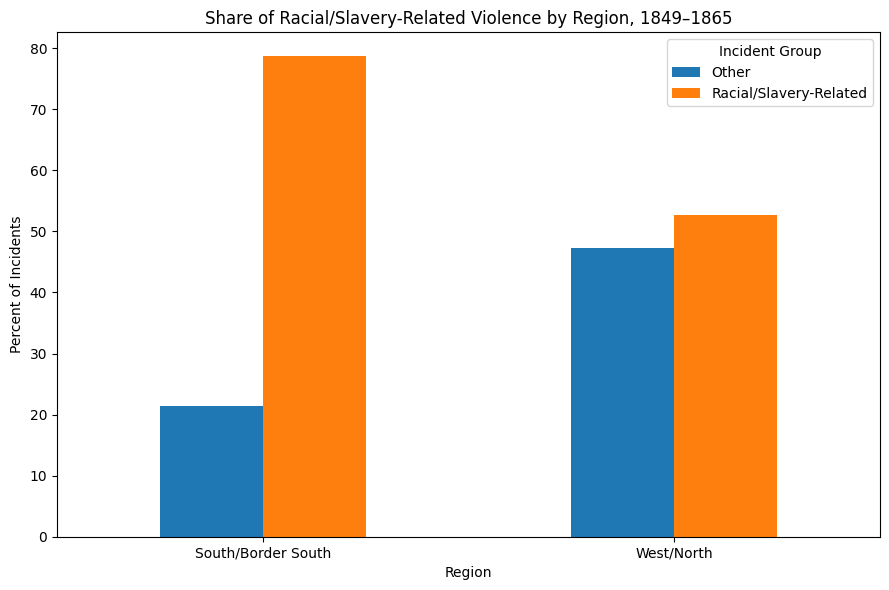

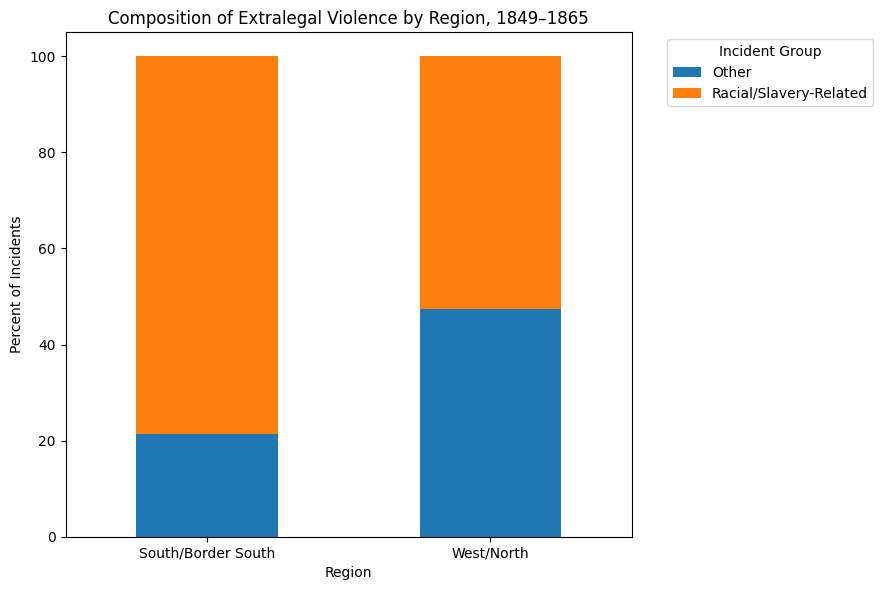


State-level counts (states with at least 4 incidents):


incident_group,Other,Racial/Slavery-Related
State,,
Colorado,25,3
Iowa,25,1
Illinois,13,0
California,12,78
Maryland,8,1
Nebraska,7,0
Kansas,6,15
New York,5,2
Pennsylvania,4,2


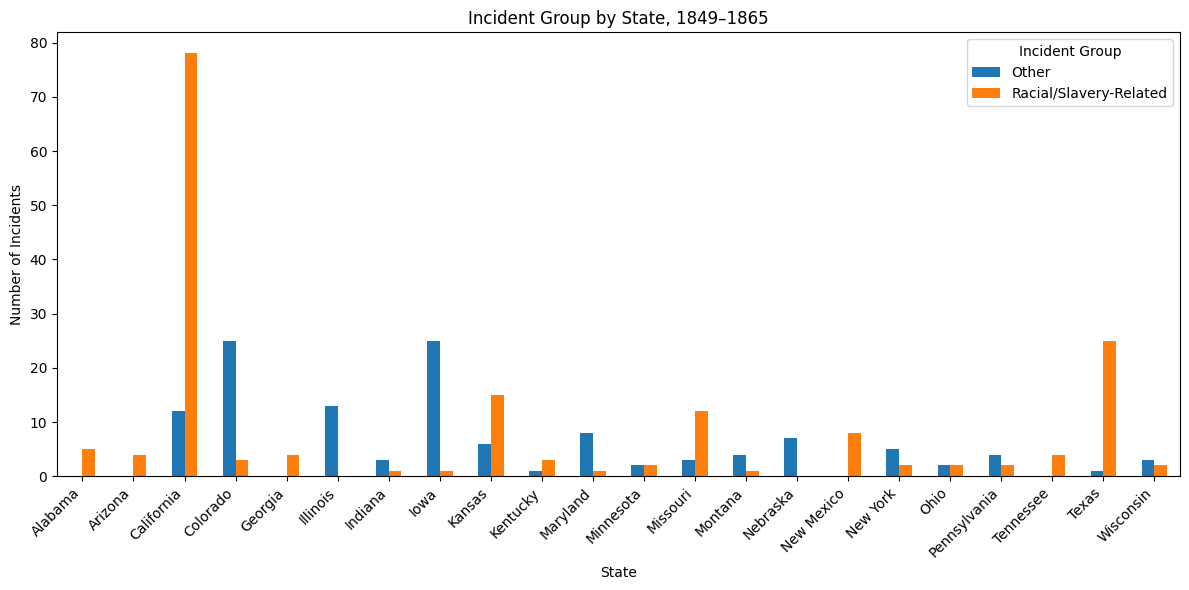


Percentages by time period:


incident_group,Other,Racial/Slavery-Related
period,,
1849–1860,34.17,65.83
1861–1865,62.50,37.50


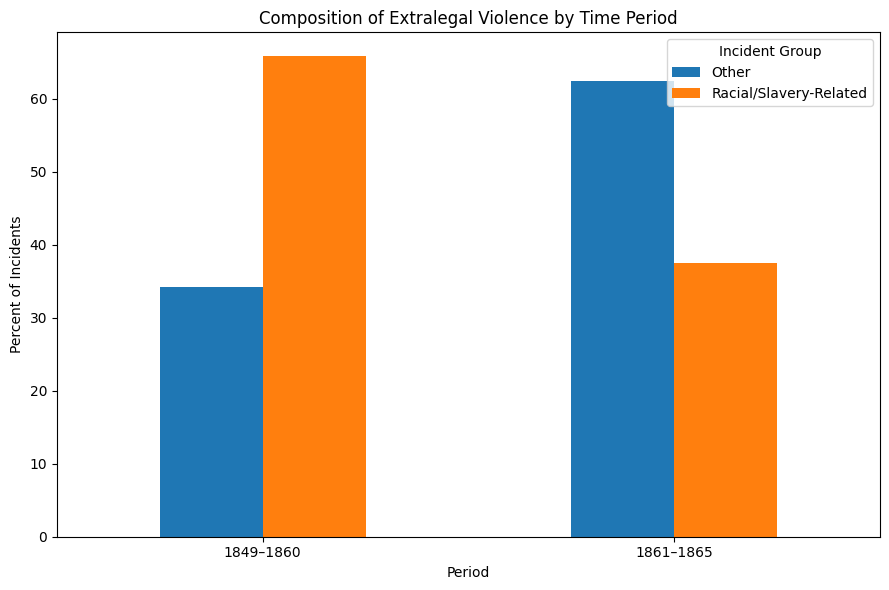


Top words in racial/slavery-related descriptions:


,count
alleged,110
murder,84
lynched,57
hanged,54
mexican,35
black,33
unknown,32
enslaved,29
killed,29
hanging,24



Top words in other descriptions:


,count
alleged,47
killed,36
horse,33
him,33
hanged,29
lynched,25
murder,23
theft,21
vigilantes,21
mob,19


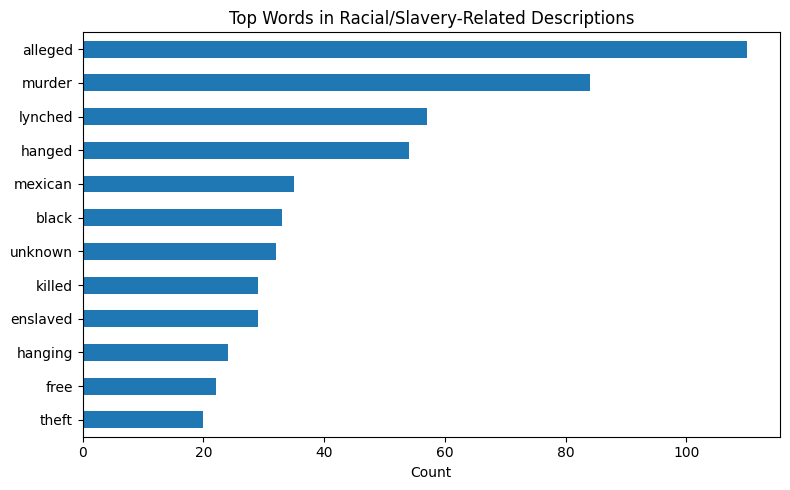

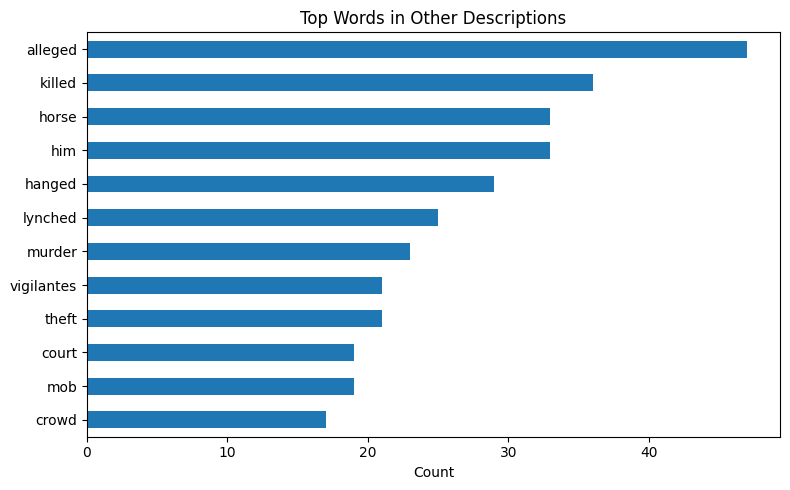


Saved cleaned dataset as 'cleaned_killings_1849_1865.csv'


In [10]:
# ============================================
# MVP PROJECT: Extralegal Killings, 1849–1865
# Comparative Pipeline
# Historical Question:
# Did different regions exhibit distinct types
# of extralegal violence, with racialized or
# slavery-related violence forming a larger share
# of incidents in the South/Border South than in
# the West/North between 1849 and 1865?
# ============================================

# -----------------------------
# 1. Import libraries
# -----------------------------
import json
import pandas as pd
import matplotlib.pyplot as plt
import re

# -----------------------------
# 2. Load the GeoJSON file
# -----------------------------
file_path = "Year_1849_1865.geojson"

with open(file_path, "r", encoding="utf-8") as f:
    geojson_data = json.load(f)

records = [feature["properties"] for feature in geojson_data["features"]]
df = pd.DataFrame(records)

print("Dataset loaded.")
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")
print("\nColumns:")
print(df.columns.tolist())

display(df.head())

# -----------------------------
# 3. Basic cleaning
# -----------------------------
df = df.copy()
df.columns = [col.strip() for col in df.columns]

text_cols = [
    "State", "Sublocation", "Location", "Description", "Source", "Type",
    "Rioter Classification", "Target Classification", "Actions", "Note"
]

for col in text_cols:
    if col in df.columns:
        df[col] = df[col].fillna("").astype(str).str.strip()

# Numeric columns
if "Year" in df.columns:
    df["Year"] = pd.to_numeric(df["Year"], errors="coerce")
    df = df.dropna(subset=["Year"])
    df["Year"] = df["Year"].astype(int)

for col in ["Lat", "Long", "Recorded # Killed", "Recorded # Injured"]:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

print("\nShape after cleaning:", df.shape)

# -----------------------------
# 4. Create the two required subsets:
# South/Border South vs West/North
# -----------------------------
south_border_states = {
    "Delaware", "Maryland", "Virginia", "North Carolina", "South Carolina",
    "Georgia", "Kentucky", "Tennessee", "Louisiana", "Mississippi",
    "Alabama", "Missouri", "Arkansas", "Florida", "Texas"
}

def assign_region(state):
    state = str(state).strip()
    if state in south_border_states:
        return "South/Border South"
    return "West/North"

df["region"] = df["State"].apply(assign_region)

print("\nCounts by region:")
display(df["region"].value_counts().to_frame("count"))

# -----------------------------
# 5. Classify incident type
# Main split:
# Racial/Slavery-Related vs Other
#
# Here we use the dataset's existing Type field.
# -----------------------------
def classify_incident_type(type_text):
    type_text = str(type_text).lower()
    if ("racial" in type_text) or ("slavery" in type_text):
        return "Racial/Slavery-Related"
    return "Other"

df["incident_group"] = df["Type"].apply(classify_incident_type)

print("\nCounts by incident group:")
display(df["incident_group"].value_counts().to_frame("count"))

# -----------------------------
# 6. Main comparative calculation
# For each region, calculate the percentage of
# incidents that are racial/slavery-related vs other
# -----------------------------
comparison_counts = pd.crosstab(df["region"], df["incident_group"])
comparison_percent = pd.crosstab(df["region"], df["incident_group"], normalize="index") * 100

print("\nRaw counts by region and incident group:")
display(comparison_counts)

print("\nPercentages within each region:")
display(comparison_percent.round(2))

# -----------------------------
# 7. Comparative visualization
# Grouped bar chart
# -----------------------------
comparison_percent.plot(kind="bar", figsize=(9, 6))
plt.title("Share of Racial/Slavery-Related Violence by Region, 1849–1865")
plt.xlabel("Region")
plt.ylabel("Percent of Incidents")
plt.xticks(rotation=0)
plt.legend(title="Incident Group")
plt.tight_layout()
plt.show()

# -----------------------------
# 8. Alternative comparative visualization
# Stacked bar chart (often easier to read proportions)
# -----------------------------
comparison_percent.plot(kind="bar", stacked=True, figsize=(9, 6))
plt.title("Composition of Extralegal Violence by Region, 1849–1865")
plt.xlabel("Region")
plt.ylabel("Percent of Incidents")
plt.xticks(rotation=0)
plt.legend(title="Incident Group", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

# -----------------------------
# 9. State-level breakdown
# This gives more geographic depth
# -----------------------------
state_counts = pd.crosstab(df["State"], df["incident_group"])
state_counts["total_incidents"] = state_counts.sum(axis=1)

# Keep states with at least 4 incidents so the graph is readable
state_counts_filtered = state_counts[state_counts["total_incidents"] >= 4].drop(columns="total_incidents")

print("\nState-level counts (states with at least 4 incidents):")
display(state_counts_filtered.sort_values(by=state_counts_filtered.columns.tolist(), ascending=False))

state_counts_filtered.plot(kind="bar", figsize=(12, 6))
plt.title("Incident Group by State, 1849–1865")
plt.xlabel("State")
plt.ylabel("Number of Incidents")
plt.xticks(rotation=45, ha="right")
plt.legend(title="Incident Group")
plt.tight_layout()
plt.show()

# -----------------------------
# 10. Optional second layer:
# Pre-Civil War vs Civil War years
# This is NOT your main comparison, but it adds
# historical depth.
# -----------------------------
def assign_period(year):
    if year <= 1860:
        return "1849–1860"
    return "1861–1865"

df["period"] = df["Year"].apply(assign_period)

period_percent = pd.crosstab(df["period"], df["incident_group"], normalize="index") * 100

print("\nPercentages by time period:")
display(period_percent.round(2))

period_percent.plot(kind="bar", figsize=(9, 6))
plt.title("Composition of Extralegal Violence by Time Period")
plt.xlabel("Period")
plt.ylabel("Percent of Incidents")
plt.xticks(rotation=0)
plt.legend(title="Incident Group")
plt.tight_layout()
plt.show()

# -----------------------------
# 11. Description commonalities
# Compare top words in descriptions for the two categories
# This supports your "commonalities with description" idea
# -----------------------------
stopwords = {
    "the", "a", "an", "and", "or", "of", "to", "in", "on", "for", "by",
    "with", "was", "were", "is", "are", "at", "as", "from", "that", "this",
    "it", "his", "her", "their", "them", "he", "she", "they", "after",
    "before", "when", "into", "out", "then", "than", "had", "has", "have",
    "be", "been", "being", "who", "which", "also", "not", "but", "one",
    "two", "three", "said", "would", "there", "about", "upon", "january",
    "february", "march", "april", "may", "june", "july", "august",
    "september", "october", "november", "december", "men", "man"
}

def tokenize(text):
    words = re.findall(r"\b[a-z]+\b", str(text).lower())
    return [word for word in words if word not in stopwords and len(word) > 2]

def top_words(series, n=12):
    all_words = []
    for text in series.dropna():
        all_words.extend(tokenize(text))
    if len(all_words) == 0:
        return pd.Series(dtype=int)
    return pd.Series(all_words).value_counts().head(n)

racial_words = top_words(df[df["incident_group"] == "Racial/Slavery-Related"]["Description"])
other_words = top_words(df[df["incident_group"] == "Other"]["Description"])

print("\nTop words in racial/slavery-related descriptions:")
display(racial_words.to_frame("count"))

print("\nTop words in other descriptions:")
display(other_words.to_frame("count"))

if len(racial_words) > 0:
    racial_words.sort_values().plot(kind="barh", figsize=(8, 5))
    plt.title("Top Words in Racial/Slavery-Related Descriptions")
    plt.xlabel("Count")
    plt.tight_layout()
    plt.show()

if len(other_words) > 0:
    other_words.sort_values().plot(kind="barh", figsize=(8, 5))
    plt.title("Top Words in Other Descriptions")
    plt.xlabel("Count")
    plt.tight_layout()
    plt.show()

# -----------------------------
# 12. Save cleaned data
# -----------------------------
df.to_csv("cleaned_killings_1849_1865.csv", index=False)
print("\nSaved cleaned dataset as 'cleaned_killings_1849_1865.csv'")